# Pregunta 9: PDFs de dry spells en 4 cuencas

## Objetivo
En **4 cuencas** distintas, calcular la **PDF** de la **duración de dry spells** para:

| Fuente | Periodo |
|--------|---------|
| **CR2MET** | Histórico 1980–2014 |
| **ALADIN histórico** | 1980–2014 |
| **ALADIN futuro** | 2040–2074 (SSP5-8.5) |

Bajo los **3 criterios de umbral** del punto 4:

| Criterio | CR2MET | ALADIN |
|----------|--------|--------|
| **i. Global** | `< 1 mm/día` | `< τ*_dominio` (5.285 mm; iguala fwet integrado en histórico) |
| **ii. Mismo umbral** | `< 1 mm/día` | `< 1 mm/día` |
| **iii. Local** | `< 1 mm/día` | `< τ*(x,y)` local (calibrado en histórico, fijo para futuro) |

## Cuencas
1. **Loa** (norte árido) 2. **Maipo** (centro) 3. **Maule** (centro-sur) 4. **Biobío** (sur)

## Metodología
- Grilla de referencia: **ALADIN CHP12**; CR2MET interpolado linealmente.
- **Pool regional:** se agrupan todas las duraciones de dry spells de los píxeles dentro de cada cuenca.
- Solo se procesan celdas con máscara de cuenca activa; **NaN no se tratan como días secos**.
- Se excluyen spells **censurados** al inicio o fin de la serie temporal.
- **Histograma de duraciones:** bins logarítmicos en el eje x; altura = conteos / ancho de bin, de modo que **∫ f(t) dt = n_spells** (integra al número total de dry spells del pool, no a 1).
- Se generan figuras con eje y **lineal** y con eje y **logarítmico**.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
from IPython.display import display
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

# =====================================================================
# CONFIGURACION
# =====================================================================
HIST_START = '1980-01-01'
HIST_END = '2014-12-31'
FUT_START = '2040-01-01'
FUT_END = '2074-12-31'
FUTURE_SCENARIO = 'ssp585'

TAU_CR2MET_REF = 1.0
TAU_ALADIN_DOMINIO = 5.285  # Pregunta 6: iguala fwet integrado CR2MET(1 mm)
BISECTION_TAU_MAX = 15.0
BISECTION_TOL = 1e-4

PDF_BINS = 25
MIN_DURATION = 1
EXCLUDE_BOUNDARY_SPELLS = True

BASIN_SPECS = {
    'Loa':    {'bounds': (-69.8, -68.2, -24.0, -21.5), 'color': 'goldenrod'},
    'Maipo':  {'bounds': (-71.8, -69.8, -34.5, -33.2), 'color': 'firebrick'},
    'Maule':  {'bounds': (-72.8, -71.0, -36.5, -34.8), 'color': 'darkorange'},
    'Biobio': {'bounds': (-73.8, -71.5, -38.5, -36.5), 'color': 'forestgreen'},
}

DATASETS_STYLE = {
    'CR2MET (hist)':   {'color': 'black',     'ls': '-',  'lw': 2.2},
    'ALADIN (hist)':   {'color': 'steelblue', 'ls': '-',  'lw': 2.0},
    'ALADIN (futuro)': {'color': 'crimson',   'ls': '--', 'lw': 2.0},
}

SCENARIOS = {
    'i_global': {
        'title': 'Criterio i — τ* global (5.285 mm en ALADIN)',
        'thresh_cr2': TAU_CR2MET_REF,
        'thresh_ala_key': 'global',
    },
    'ii_mismo': {
        'title': 'Criterio ii — mismo umbral (1 mm)',
        'thresh_cr2': TAU_CR2MET_REF,
        'thresh_ala_key': 'same',
    },
    'iii_local': {
        'title': 'Criterio iii — τ* local por píxel',
        'thresh_cr2': TAU_CR2MET_REF,
        'thresh_ala_key': 'local',
    },
}


def load_chile_geometry():
    reader = shpreader.Reader(
        shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
    )
    geoms = [r.geometry for r in reader.records()
             if r.attributes.get('NAME') == 'Chile' or r.attributes.get('ADMIN') == 'Chile']
    return unary_union(geoms)


def build_chile_mask_on_aladin_grid(lat2d, lon2d, geometry):
    prepared = prep(geometry)
    flat = np.fromiter(
        (prepared.contains(Point(float(x), float(y))) or geometry.touches(Point(float(x), float(y)))
         for y, x in zip(lat2d.ravel(), lon2d.ravel())),
        dtype=bool, count=lat2d.size,
    )
    return flat.reshape(lat2d.shape)


def build_basin_mask(lat2d, lon2d, chile_mask_bool, bounds):
    lon_min, lon_max, lat_min, lat_max = bounds
    return (
        (lon2d >= lon_min) & (lon2d <= lon_max) &
        (lat2d >= lat_min) & (lat2d <= lat_max) & chile_mask_bool
    )


def open_aladin_period(start, end, scenario=None):
    if scenario is None:
        files = sorted(Path('pr1').glob('pr_CHP12_*_historical_*.nc'))
    else:
        files = sorted(Path('pr1').glob(f'pr_CHP12_*_{scenario}_*.nc'))
    ds = xr.open_mfdataset([str(p) for p in files], use_cftime=True, chunks={'time': 365})
    return ds['pr'].sel(time=slice(start, end)) * 86400.0


def open_cr2met_period(start, end):
    ds = xr.open_mfdataset('./pr/CR2MET_pr_v2.5_day_*.nc', chunks={'time': 365})
    return ds['pr'].sel(time=slice(start, end))


def regrid_cr2met_to_aladin(pr_cr2met, template):
    return pr_cr2met.interp(lat=template['lat'], lon=template['lon'], method='linear')


print('1/3: Cargando datos históricos y futuros...')
pr_ala_hist = open_aladin_period(HIST_START, HIST_END)
pr_ala_fut = open_aladin_period(FUT_START, FUT_END, scenario=FUTURE_SCENARIO)
pr_cr2_hist = regrid_cr2met_to_aladin(open_cr2met_period(HIST_START, HIST_END), pr_ala_hist)

chile_geom = load_chile_geometry()
lat2d = pr_ala_hist['lat'].values
lon2d = pr_ala_hist['lon'].values
chile_mask_bool = build_chile_mask_on_aladin_grid(lat2d, lon2d, chile_geom)
chile_mask = xr.DataArray(
    chile_mask_bool,
    coords={'y': pr_ala_hist['y'], 'x': pr_ala_hist['x'],
            'lat': pr_ala_hist['lat'], 'lon': pr_ala_hist['lon']},
    dims=['y', 'x'], name='chile_mask',
)

basin_masks = {}
for name, spec in BASIN_SPECS.items():
    bm = build_basin_mask(lat2d, lon2d, chile_mask_bool, spec['bounds'])
    basin_masks[name] = xr.DataArray(
        bm, coords=chile_mask.coords, dims=['y', 'x'], name=f'mask_{name}',
    )
    print(f'  {name}: {int(bm.sum())} píxeles')

print(f'Periodo hist: {HIST_START[:4]}-{HIST_END[:4]} | futuro: {FUT_START[:4]}-{FUT_END[:4]} ({FUTURE_SCENARIO})')

1/3: Cargando datos históricos y futuros...
  Loa: 298 píxeles
  Maipo: 154 píxeles
  Maule: 171 píxeles
  Biobio: 243 píxeles
Periodo hist: 1980-2014 | futuro: 2040-2074 (ssp585)


In [ ]:
# =====================================================================
# UMBRALES + EXTRACCIÓN DE DRY SPELLS (corregida)
# =====================================================================
def wet_fraction_1d(pr_series, threshold):
    x = np.asarray(pr_series, dtype=float)
    x = x[np.isfinite(x)]
    return float((x >= threshold).mean()) if x.size else np.nan


def find_threshold_for_target_1d(pr_series, target_fraction, tau_max=BISECTION_TAU_MAX, tol=BISECTION_TOL):
    if not np.isfinite(target_fraction):
        return np.nan
    f0, fmax = wet_fraction_1d(pr_series, 0.0), wet_fraction_1d(pr_series, tau_max)
    if target_fraction > f0 + tol or target_fraction < fmax - tol:
        return np.nan
    lo, hi = 0.0, tau_max
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        fmid = wet_fraction_1d(pr_series, mid)
        if abs(fmid - target_fraction) <= tol:
            return mid
        lo, hi = (mid, hi) if fmid > target_fraction else (lo, mid)
    return 0.5 * (lo + hi)


def pixelwise_local_aladin_threshold(pr_cr2, pr_aladin, tau_cr2, mask_da):
    f_target = (pr_cr2 >= tau_cr2).mean(dim='time').where(mask_da)
    stacked = xr.Dataset({
        'pr_ala': pr_aladin.stack(cell=('y', 'x')),
        'f_target': f_target.stack(cell=('y', 'x')),
    }).compute()
    n_cells = stacked.sizes['cell']
    tau_star = np.full(n_cells, np.nan, dtype=np.float32)
    for idx in range(n_cells):
        ft = float(stacked['f_target'].values[idx])
        if np.isfinite(ft):
            tau_star[idx] = find_threshold_for_target_1d(stacked['pr_ala'].values[:, idx], ft)
    tau_da = xr.DataArray(tau_star, coords={'cell': stacked['cell']}, dims=['cell']).unstack('cell')
    return tau_da.assign_coords(lat=mask_da['lat'], lon=mask_da['lon'])


def time_to_year(t):
    if hasattr(t, 'year'):
        return int(t.year)
    return int(pd.Timestamp(t).year)


def dry_bool_1d(col):
    """Convierte serie seca/mojada a bool seguro: NaN -> no seco."""
    col = np.asarray(col, dtype=float)
    return np.isfinite(col) & (col > 0.5)


def run_lengths_1d(dry_bool):
    dry_bool = np.asarray(dry_bool, dtype=bool)
    if not np.any(dry_bool):
        return np.array([], dtype=np.int32), np.array([], dtype=np.int32), np.array([], dtype=np.int32)
    padded = np.r_[False, dry_bool, False]
    dx = np.diff(padded.astype(np.int8))
    starts, ends = np.where(dx == 1)[0], np.where(dx == -1)[0]
    return starts, ends, (ends - starts).astype(np.int32)


def extract_basin_spell_records(pr, dry_threshold, basin_mask, exclude_boundary=EXCLUDE_BOUNDARY_SPELLS):
    """Pool regional: duraciones de spells por píxel dentro de la cuenca."""
    is_dry = (pr < dry_threshold).where(basin_mask)
    stacked = is_dry.stack(cell=('y', 'x')).transpose('time', 'cell').compute()
    times = stacked['time'].values
    vals = stacked.values
    mask_flat = basin_mask.stack(cell=('y', 'x')).values
    n_time = vals.shape[0]
    records = []

    for idx in range(vals.shape[1]):
        if not mask_flat[idx]:
            continue
        dry = dry_bool_1d(vals[:, idx])
        if not np.any(dry):
            continue
        starts, ends, durations = run_lengths_1d(dry)
        for s, e, duration in zip(starts, ends, durations):
            if exclude_boundary and (s == 0 or e == n_time):
                continue
            if duration > 0:
                records.append({'start_year': time_to_year(times[s]), 'duration': int(duration)})
    return pd.DataFrame(records)


def spell_durations_from_records(spell_df):
    if spell_df.empty:
        return np.array([], dtype=np.int32)
    return spell_df['duration'].to_numpy(dtype=np.int32)


def pdf_from_durations(durations, n_bins=PDF_BINS, min_duration=MIN_DURATION):
    """Histograma con bins log: altura = conteos / ancho_bin => integral = n_spells."""
    d = np.asarray(durations, dtype=float)
    d = d[np.isfinite(d) & (d >= min_duration)]
    if d.size < 50:
        return None, None, 0
    lo = max(float(np.min(d)), min_duration)
    hi = float(np.max(d))
    if hi <= lo:
        return None, None, 0
    bins = np.logspace(np.log10(lo), np.log10(hi), n_bins + 1)
    counts, edges = np.histogram(d, bins=bins, density=False)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    heights = counts / widths  # sum(heights * widths) == n_spells
    return centers, heights, int(d.size)


def summarize_durations(durations):
    d = np.asarray(durations, dtype=float)
    d = d[np.isfinite(d) & (d >= 1)]
    if d.size == 0:
        return {}
    return {
        'n_spells': int(d.size),
        'mean_dias': float(np.mean(d)),
        'median_dias': float(np.median(d)),
        'p90_dias': float(np.percentile(d, 90)),
        'p99_dias': float(np.percentile(d, 99)),
        'max_dias': float(np.max(d)),
    }


print('2/3: Calculando τ* local (histórico) y extrayendo dry spells...')
tau_local_map = pixelwise_local_aladin_threshold(
    pr_cr2_hist.where(chile_mask), pr_ala_hist.where(chile_mask), TAU_CR2MET_REF, chile_mask,
)

THRESH_ALA = {
    'global': TAU_ALADIN_DOMINIO,
    'same': TAU_CR2MET_REF,
    'local': tau_local_map,
}

records = []
pdf_cache = {}

for scen_key, scen in SCENARIOS.items():
    tc = scen['thresh_cr2']
    ta = THRESH_ALA[scen['thresh_ala_key']]
    for basin_name, basin_mask in basin_masks.items():
        spell_dfs = {
            'CR2MET (hist)': extract_basin_spell_records(pr_cr2_hist, tc, basin_mask),
            'ALADIN (hist)': extract_basin_spell_records(pr_ala_hist, ta, basin_mask),
            'ALADIN (futuro)': extract_basin_spell_records(pr_ala_fut, ta, basin_mask),
        }
        durs = {k: spell_durations_from_records(df) for k, df in spell_dfs.items()}
        pdf_cache[(scen_key, basin_name)] = durs
        for ds_name, arr in durs.items():
            s = summarize_durations(arr)
            if s:
                records.append({
                    'criterio': scen_key,
                    'cuenca': basin_name,
                    'dataset': ds_name,
                    **s,
                })

summary_df = pd.DataFrame(records)
print('Resumen de duraciones (días) — pool regional por cuenca:')
display(summary_df.round(1))

_out = Path('_pregunta9_outputs')
_out.mkdir(exist_ok=True)
summary_df.round(3).to_csv(_out / 'resumen_pregunta9.csv', index=False)
print(f'Guardado: {_out / "resumen_pregunta9.csv"}')

2/3: Calculando τ* local (histórico) y extrayendo dry spells...
Resumen de duraciones (días) — pool regional por cuenca:


,criterio,cuenca,dataset,n_spells,mean_dias,median_dias,p90_dias,p99_dias,max_dias
0,i_global,Loa,CR2MET (hist),55015,65.6,23.0,185.0,456.0,1419.0
1,i_global,Loa,ALADIN (hist),66267,54.6,22.0,143.0,360.0,1156.0
2,i_global,Loa,ALADIN (futuro),64043,56.6,25.0,151.0,385.0,1853.0
3,i_global,Maipo,CR2MET (hist),150209,11.0,5.0,23.0,119.0,283.0
4,i_global,Maipo,ALADIN (hist),181049,8.6,4.0,18.0,87.0,194.0
5,i_global,Maipo,ALADIN (futuro),159887,10.0,4.0,21.0,112.0,224.0
6,i_global,Maule,CR2MET (hist),184462,9.5,5.0,21.0,83.0,206.0
7,i_global,Maule,ALADIN (hist),228077,7.3,4.0,17.0,57.0,160.0
8,i_global,Maule,ALADIN (futuro),202463,8.6,4.0,19.0,76.0,188.0
9,i_global,Biobio,CR2MET (hist),344251,6.2,4.0,14.0,44.0,109.0


3/3a: PDFs con eje Y lineal (12 figuras: 4 cuencas × 3 criterios)...
--- Criterio i — τ* global (5.285 mm en ALADIN) ---


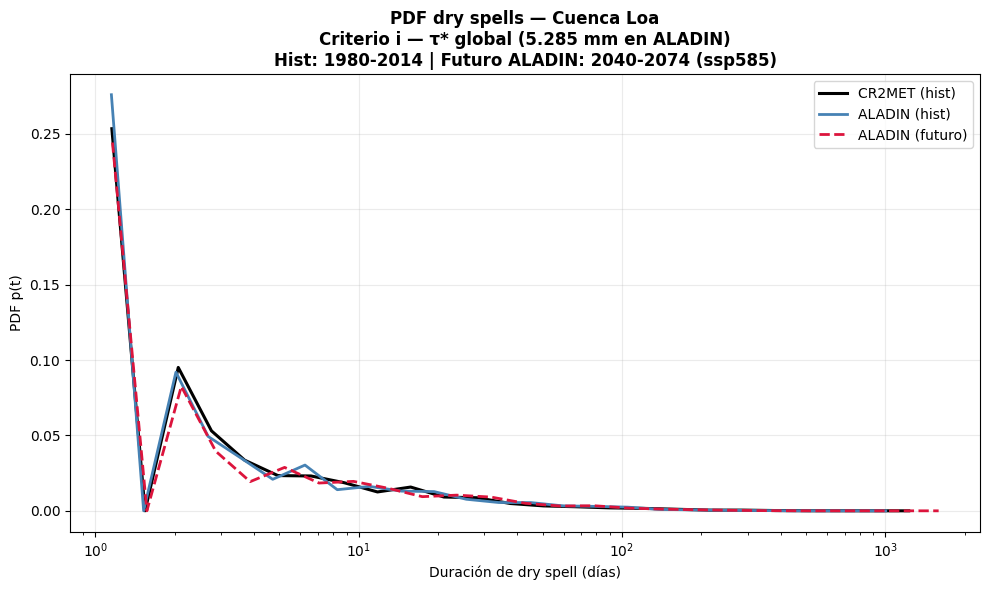

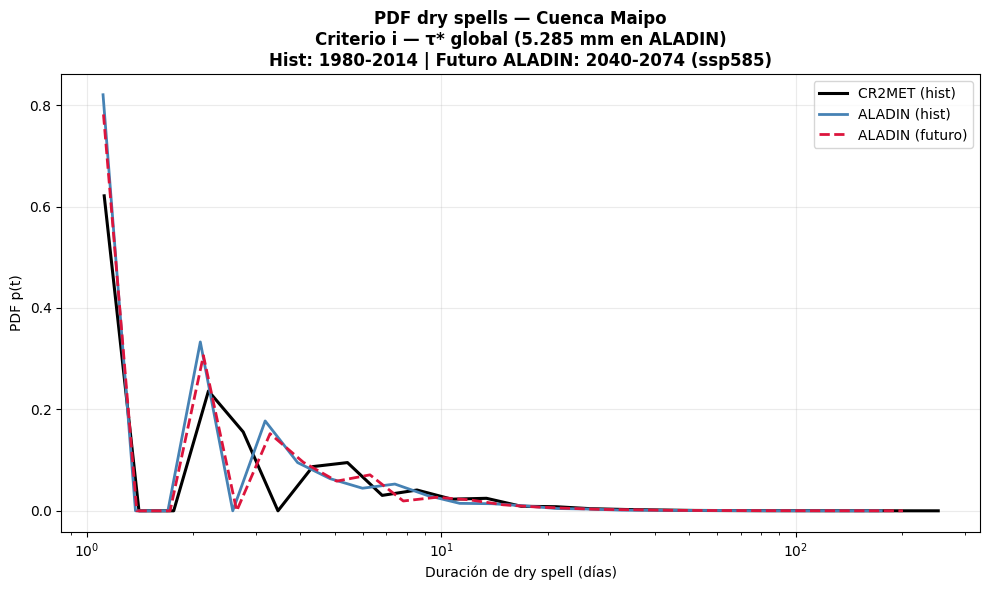

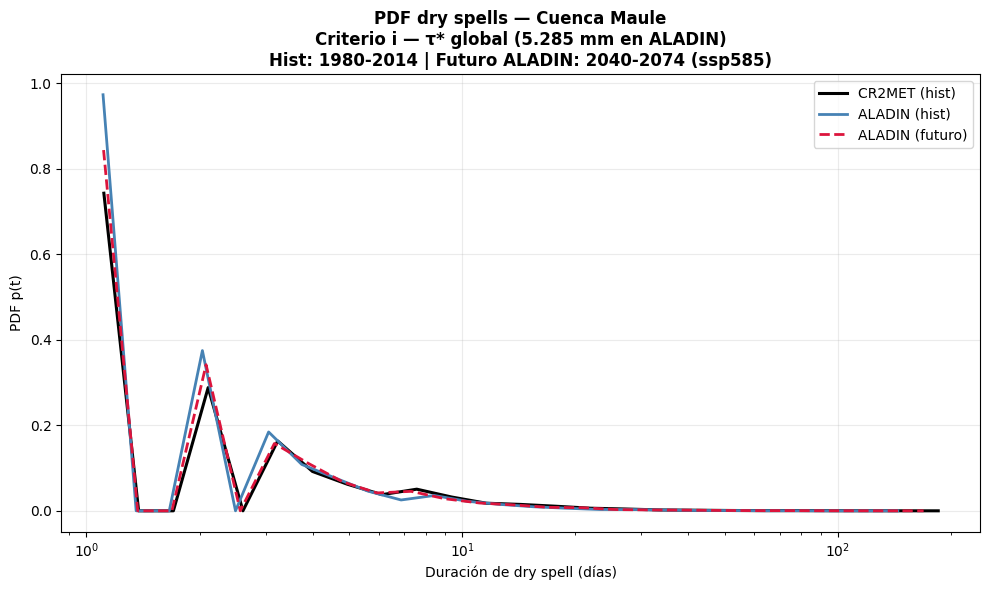

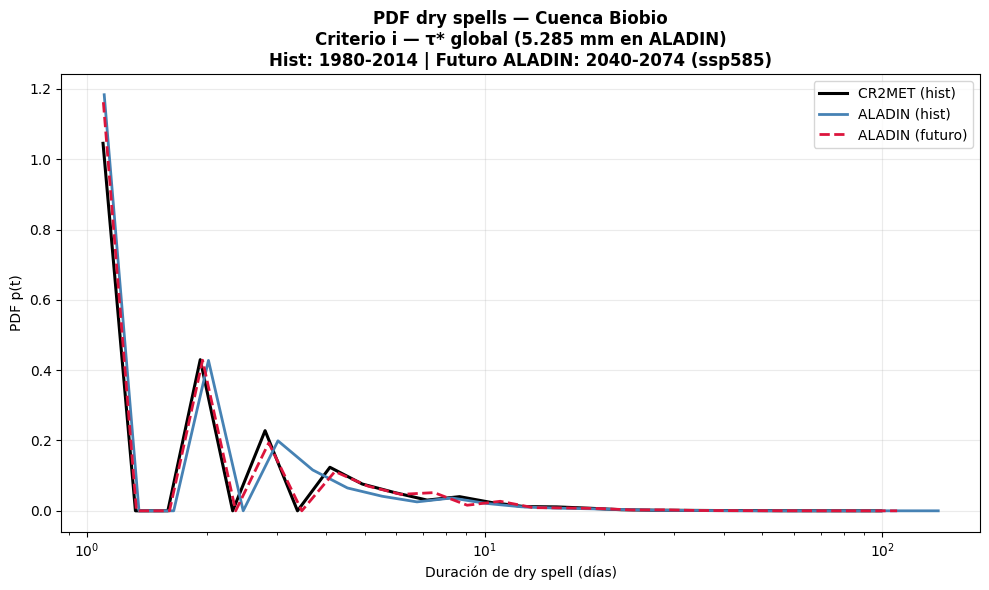

--- Criterio ii — mismo umbral (1 mm) ---


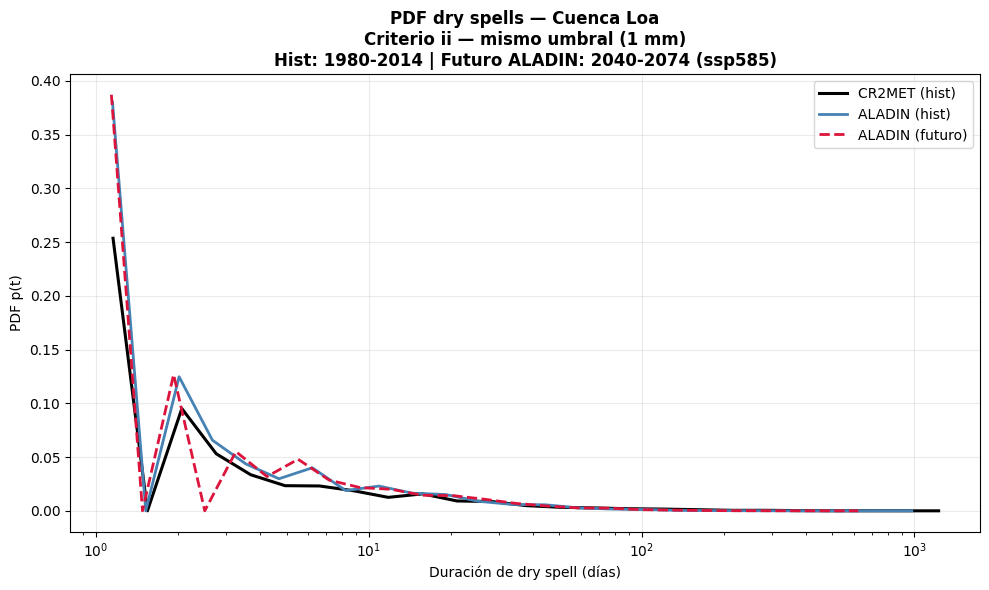

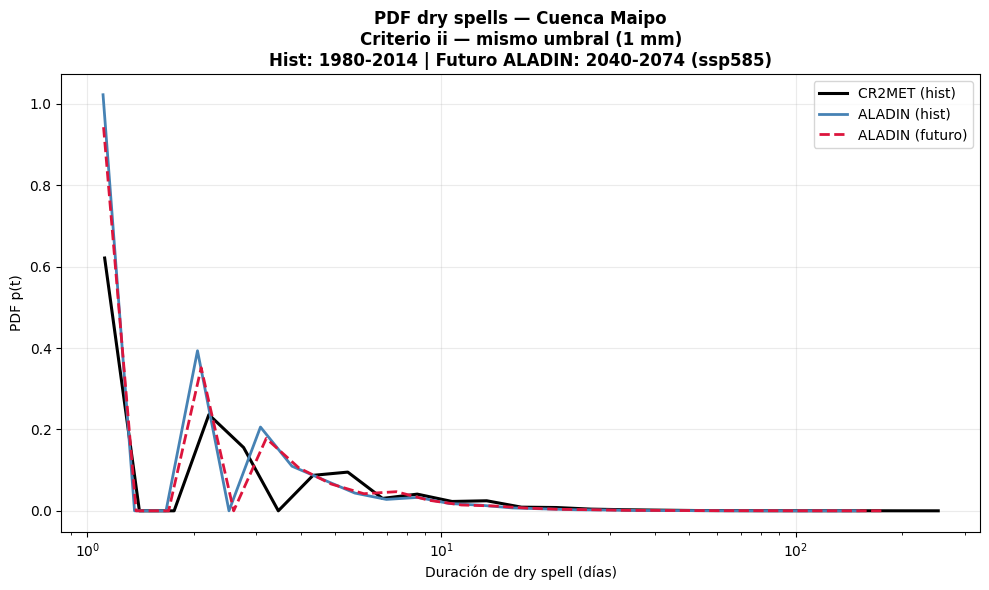

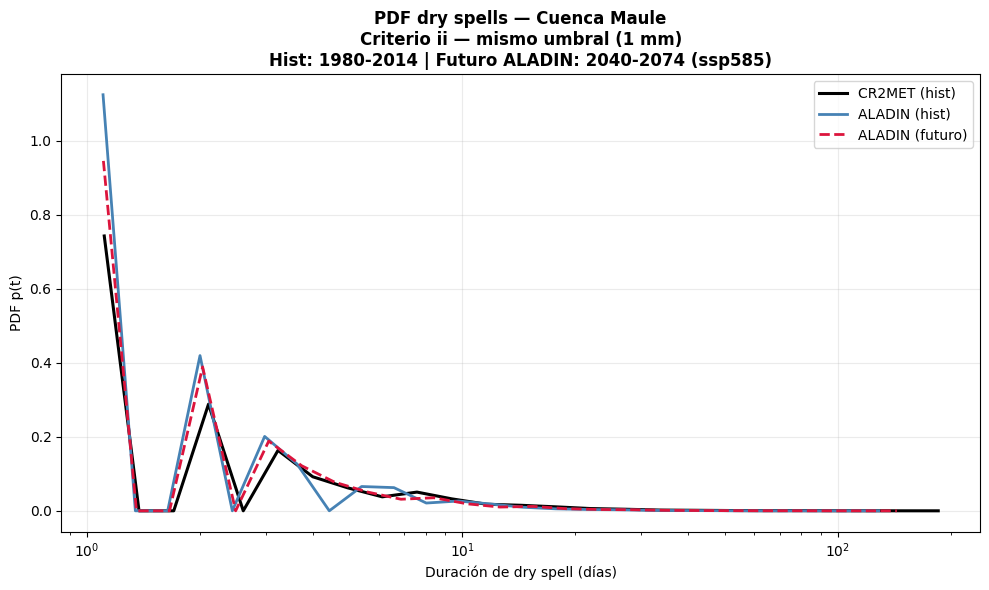

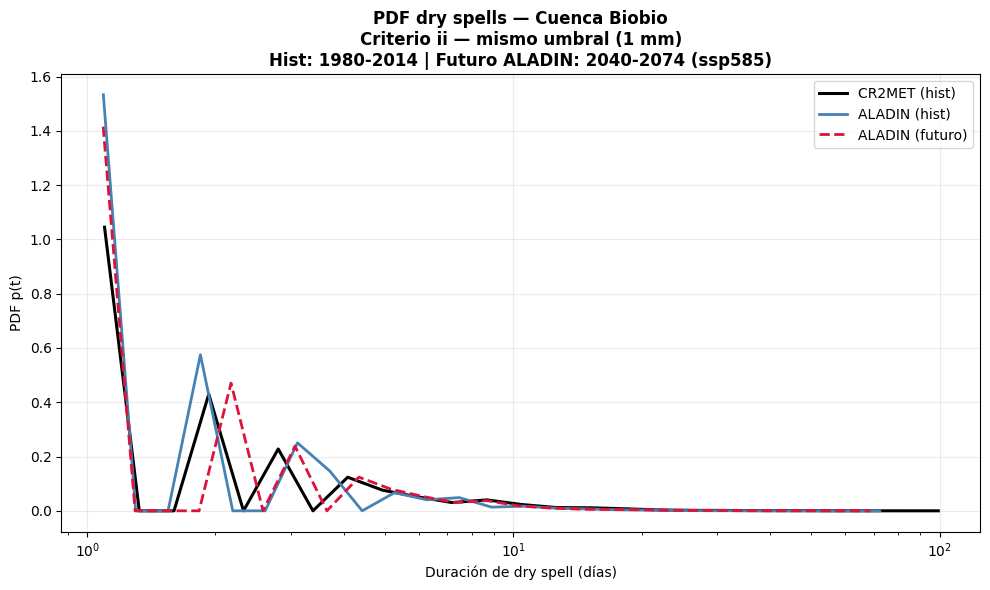

--- Criterio iii — τ* local por píxel ---


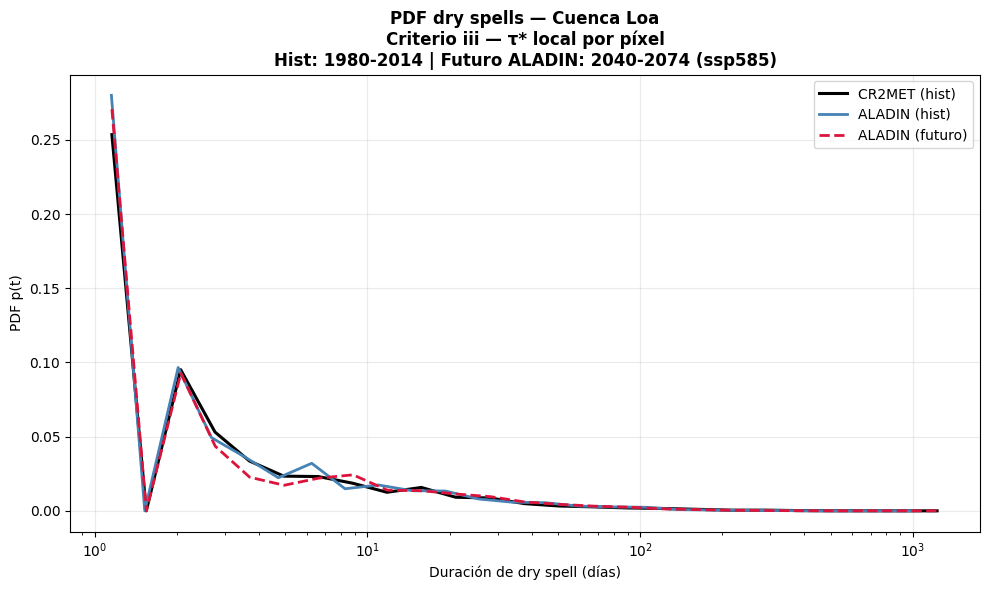

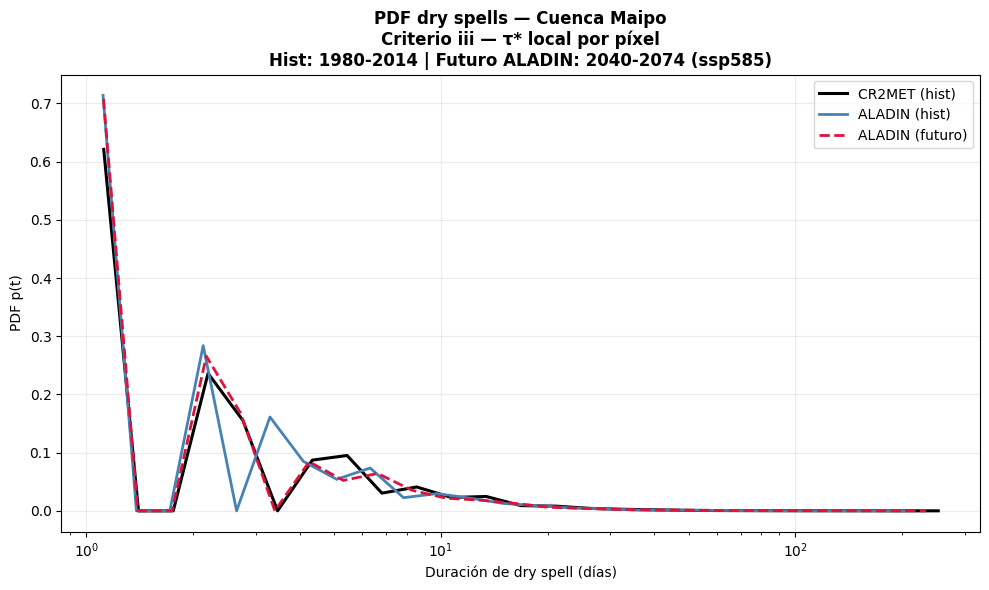

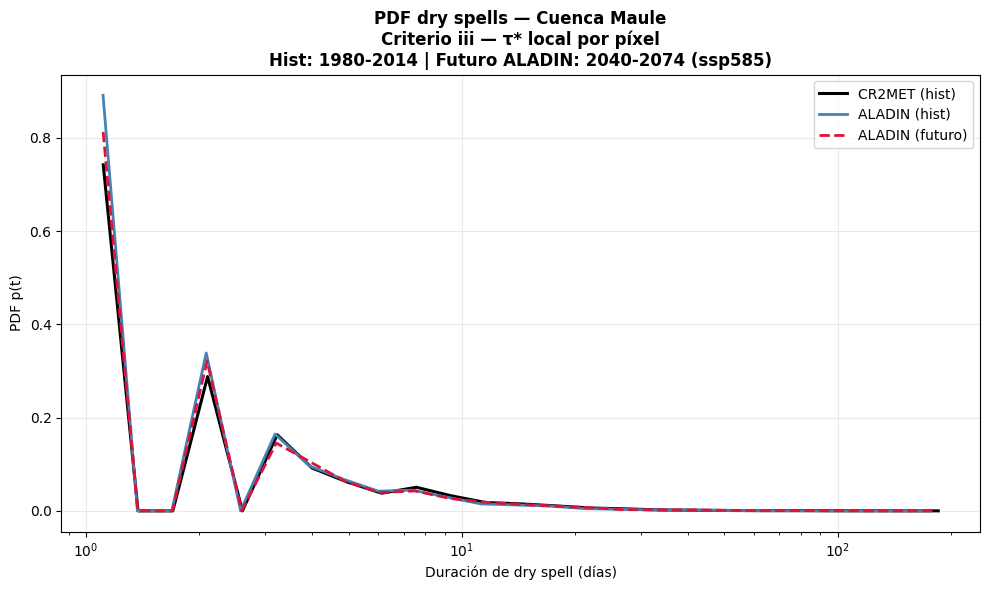

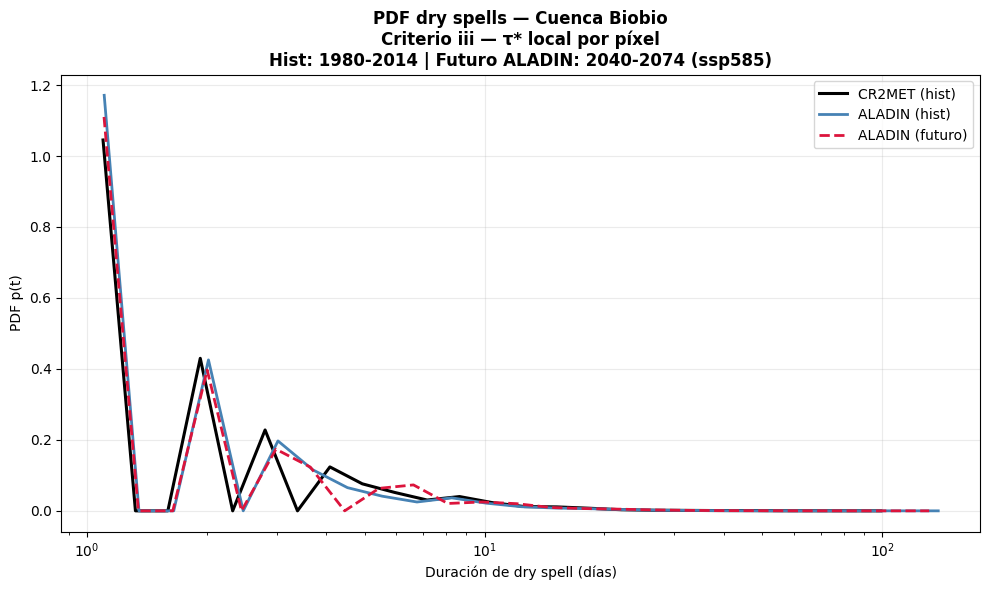

In [ ]:
# =====================================================================
# PDFs — eje Y lineal
# =====================================================================
def plot_basin_pdf(basin_name, scen_title, durs_dict, log_y=False):
    fig, ax = plt.subplots(figsize=(10, 6))

    for ds_name, style in DATASETS_STYLE.items():
        centers, heights, n_spells = pdf_from_durations(durs_dict[ds_name])
        if centers is None:
            continue
        yvals = heights.copy()
        if log_y:
            yvals = np.where(yvals > 0, yvals, np.nan)
        ax.plot(centers, yvals, label=f'{ds_name} (n={n_spells:,})', **style)

    ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    ax.set_xlabel('Duración de dry spell (días)')
    ax.set_ylabel('f(t)  [∫f dt = n_spells]' + (' [log]' if log_y else ''))
    ax.set_title(
        f'PDF dry spells — Cuenca {basin_name}\n{scen_title}\n'
        f'Hist: {HIST_START[:4]}-{HIST_END[:4]} | Futuro ALADIN: {FUT_START[:4]}-{FUT_END[:4]} ({FUTURE_SCENARIO})',
        fontweight='bold',
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


print('3/3a: PDFs con eje Y lineal (12 figuras: 4 cuencas × 3 criterios)...')
for scen_key, scen in SCENARIOS.items():
    print(f'--- {scen["title"]} ---')
    for basin_name in BASIN_SPECS:
        plot_basin_pdf(basin_name, scen['title'], pdf_cache[(scen_key, basin_name)], log_y=False)

3/3b: PDFs con eje Y logarítmico (12 figuras: 4 cuencas × 3 criterios)...
--- Criterio i — τ* global (5.285 mm en ALADIN) ---


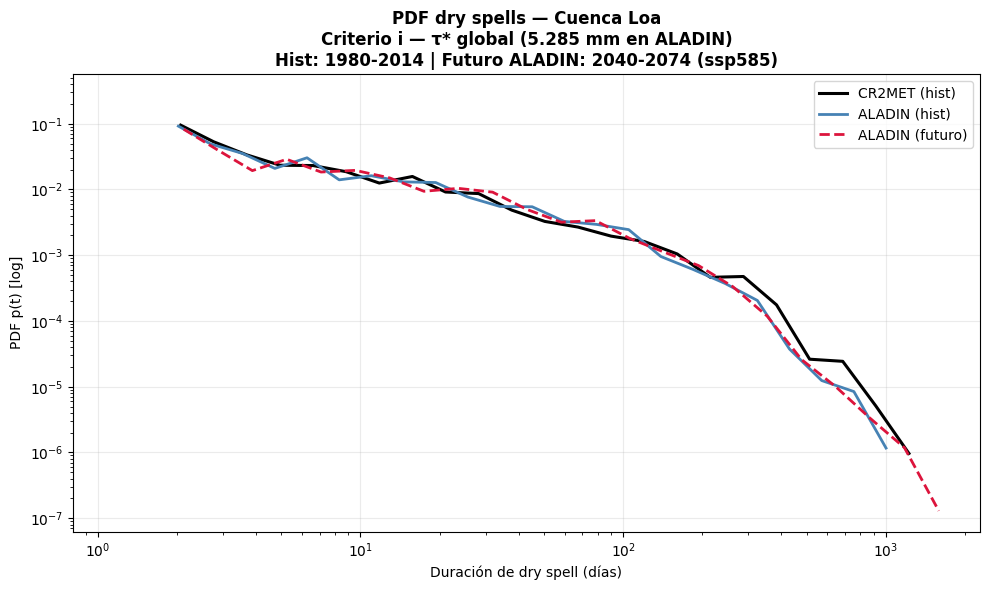

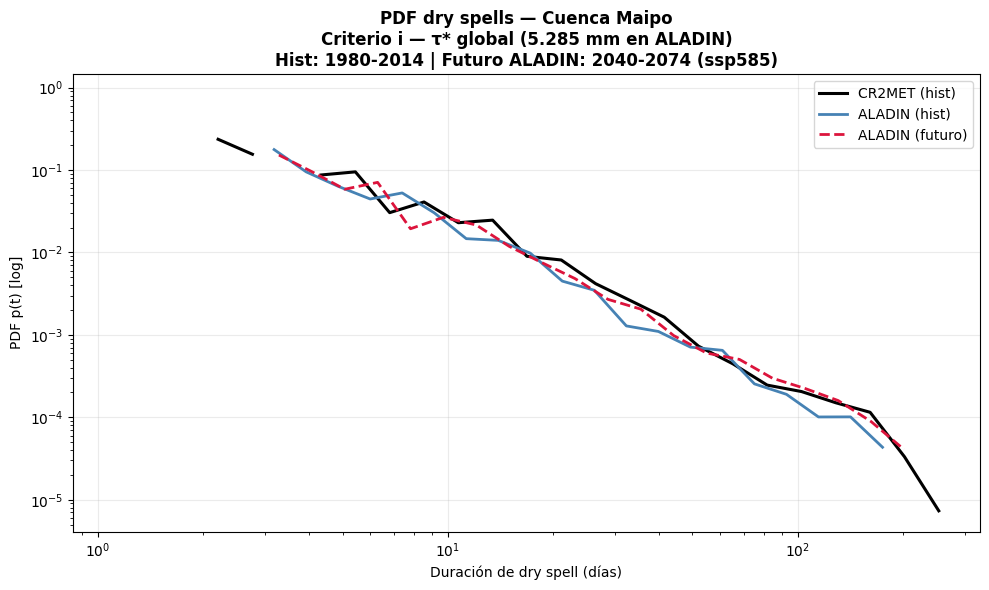

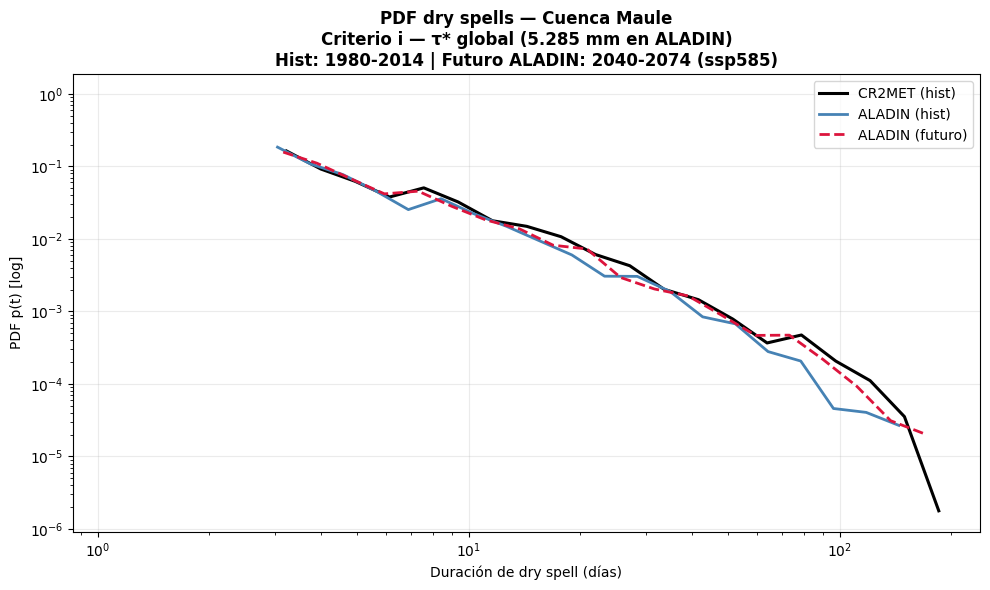

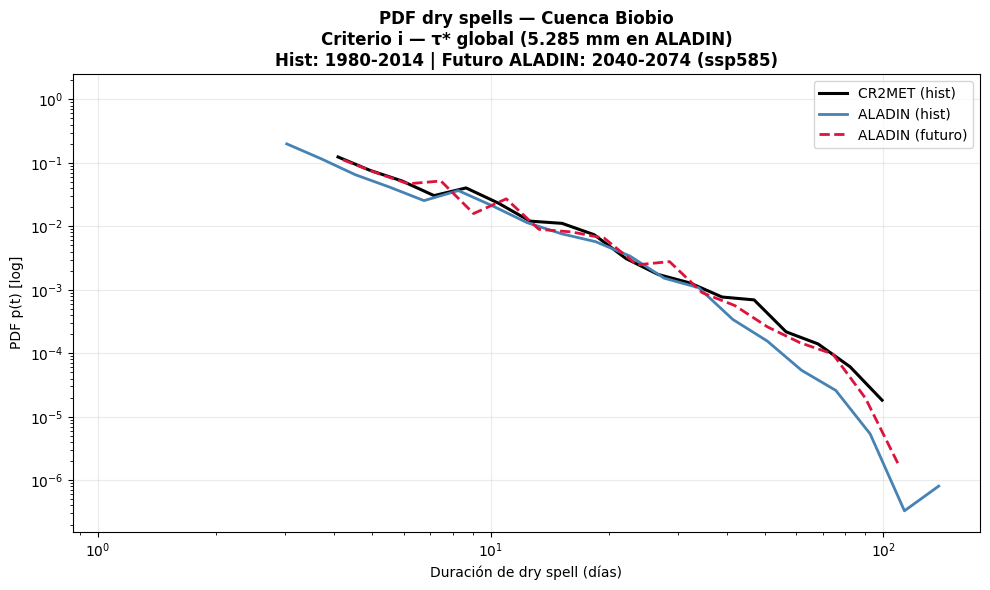

--- Criterio ii — mismo umbral (1 mm) ---


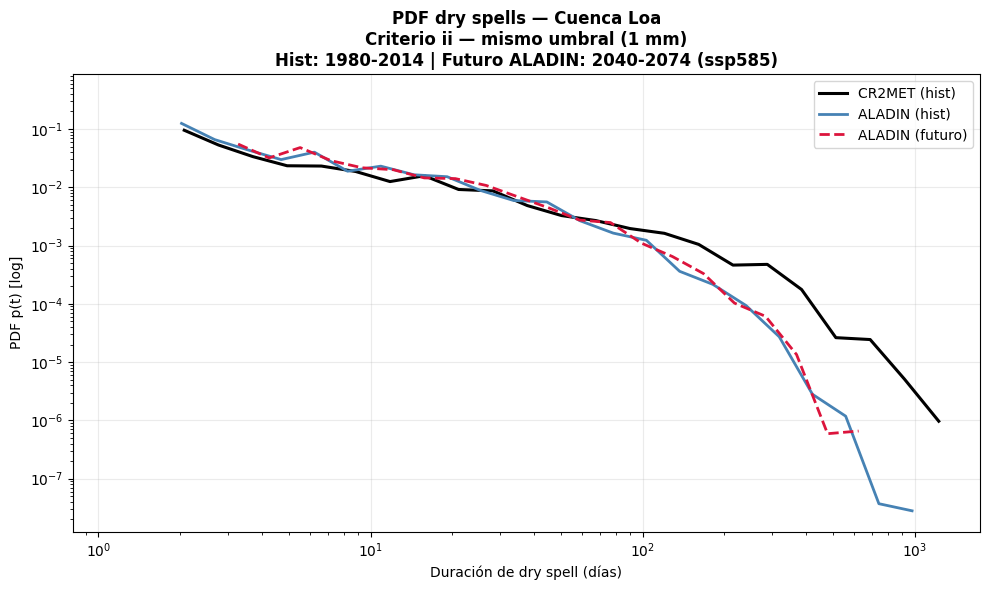

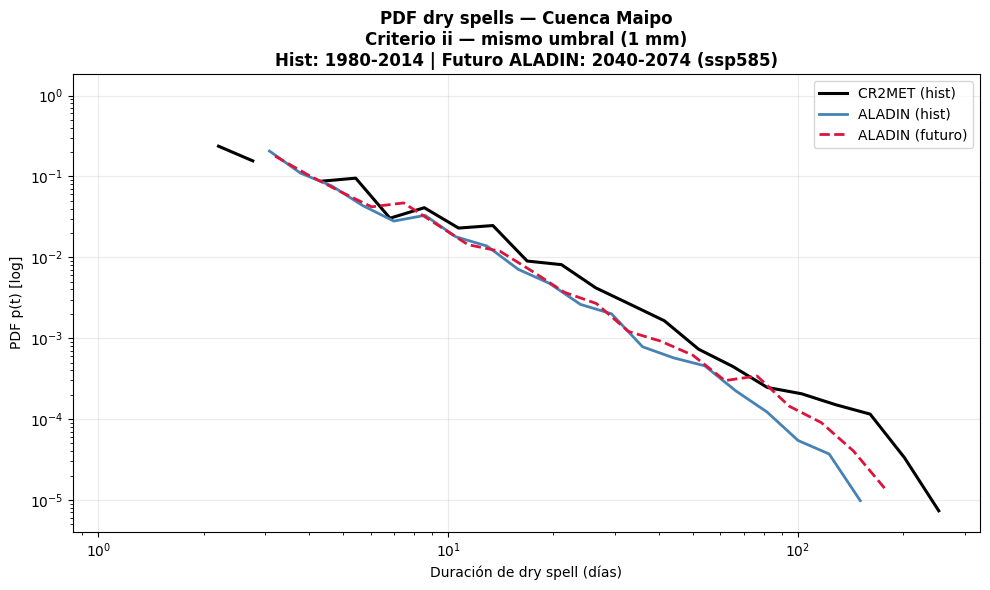

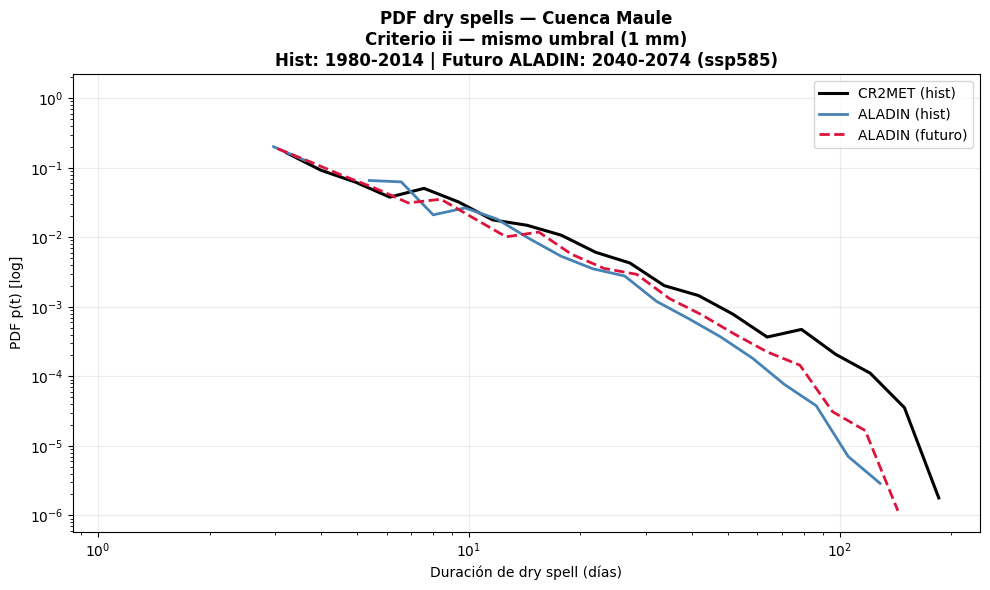

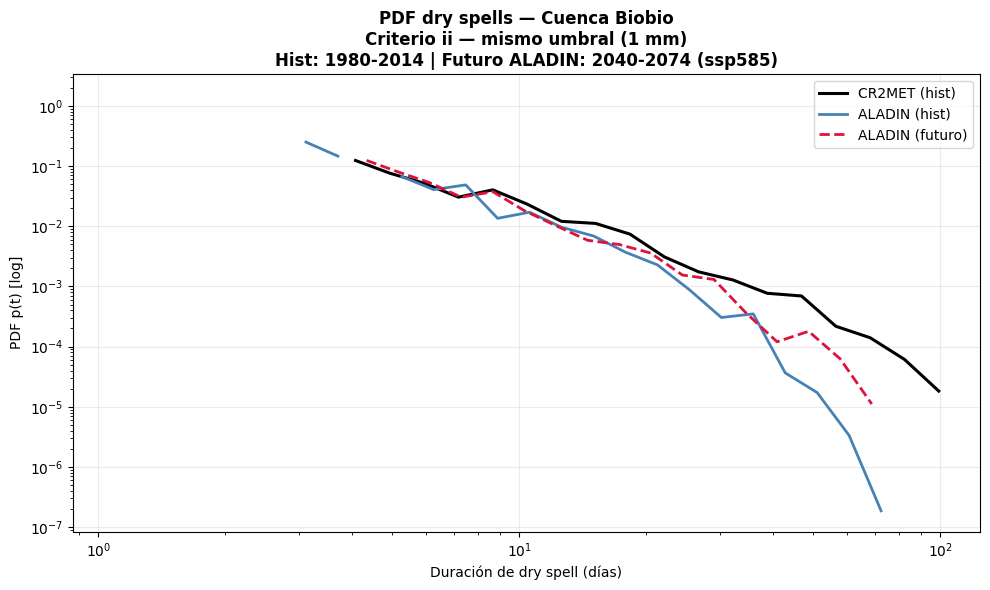

--- Criterio iii — τ* local por píxel ---


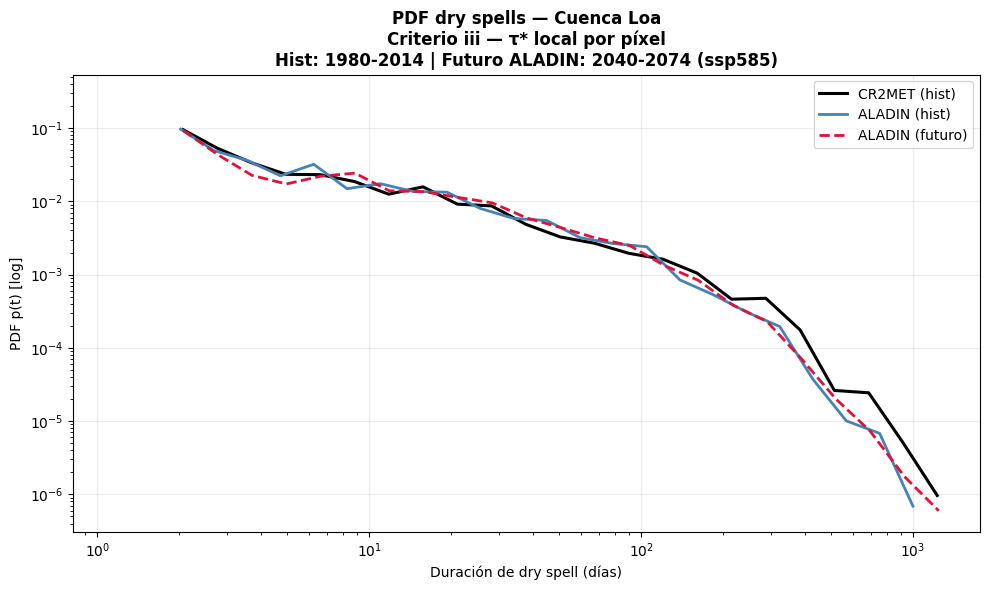

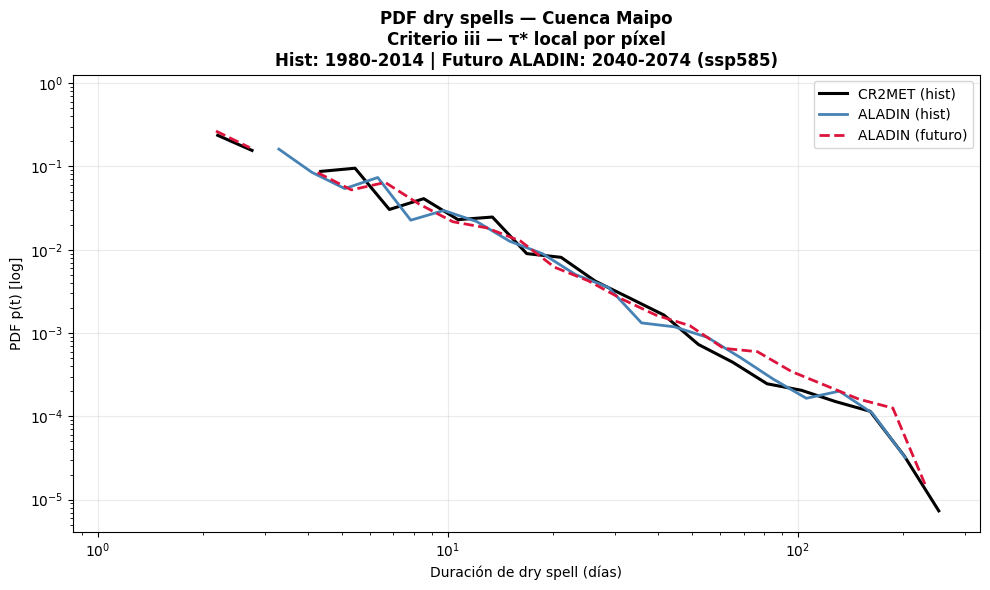

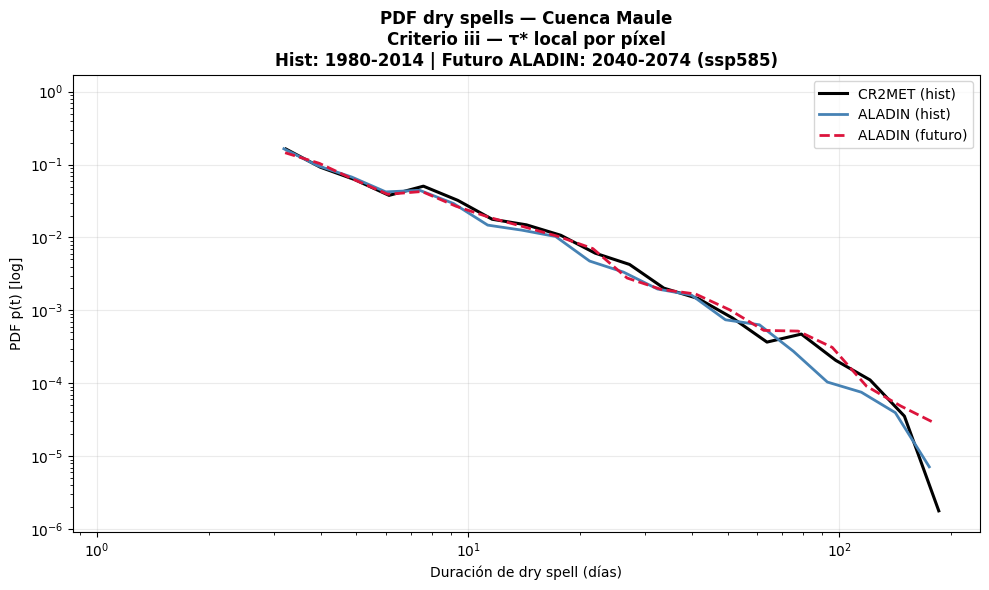

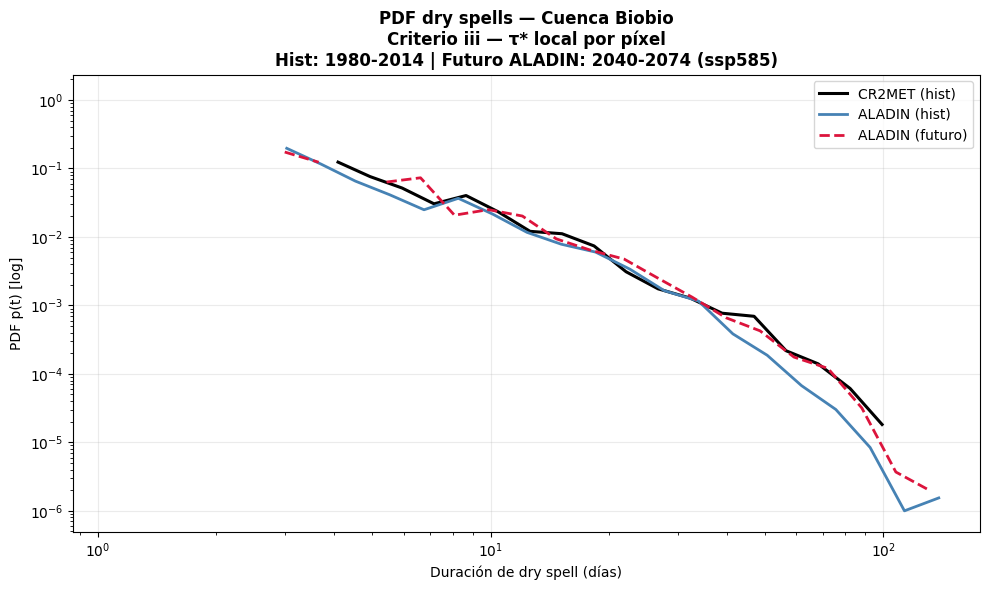

In [ ]:
# =====================================================================
# PDFs — eje Y logarítmico
# =====================================================================
print('3/3b: PDFs con eje Y logarítmico (12 figuras: 4 cuencas × 3 criterios)...')
for scen_key, scen in SCENARIOS.items():
    print(f'--- {scen["title"]} ---')
    for basin_name in BASIN_SPECS:
        plot_basin_pdf(basin_name, scen['title'], pdf_cache[(scen_key, basin_name)], log_y=True)